To begin let's set up a a joint distribution over two random variables: $$X, Y \sim p(x, y)$$ We can plot the heatmap and ground truth mutual information here.

In [129]:
import numpy as np
import matplotlib.pyplot as plt

support_size = 10

# Assign some joint probabilities, random but sum to 1
u_xy = np.random.rand(support_size, support_size)
p_xy = u_xy / np.sum(u_xy)

# p_xy = np.array([
#     [0.2, 0.1, 0.1],
#     [0.2, 0.0, 0.1],
#     [0.2, 0.1, 0.0],
# ])

""" computed for reference
pxpy = [
    [0.24 0.08 0.08]
    [0.18 0.06 0.06]
    [0.18 0.06 0.06]
]

log(p_xy/pxpy) = [
 [ -0.18232156   0.22314355   0.22314355]
 [  0.10536052 -46.05170186   0.51082562]
 [  0.10536052   0.51082562 -46.05170186]
]
"""

# Compute marginal distributions from p_xy
p_x = np.sum(p_xy, axis=1)  # sum over columns to get P(X)
p_y = np.sum(p_xy, axis=0)  # sum over rows to get P(Y)

pxpy = np.outer(p_x, p_y) # product of marginals distribution

# print(pxpy)
# print(np.log(p_xy/pxpy + 1e-20))


def mutual_information(p_xy, p_x, p_y):
    # Compute mutual information manually using p_xy, p_x, p_y
    mi = 0.0
    for i in range(len(p_xy)):
        for j in range(len(p_xy[0])):
            pxy = p_xy[i, j]
            if pxy > 0:  # Avoid log(0)
                mi += pxy * np.log(pxy / (p_x[i] * p_y[j]))

    return mi

true_mi = mutual_information(p_xy, p_x, p_y).item()

print('Mutual Information:', true_mi)

def plot_heatmap(matrix):
    plt.imshow(matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Value')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.title('Heatmap')
    plt.show()

# plot_heatmap(p_xy)

Mutual Information: 0.18510107394837735


A naive method to compute the mutual information given $n$ samples $$\mathcal{D} = \{(x_i, y_i)\}_{[n]}$$ woudld be to form a histogram (i.e. empirical joint distribution) and compute the mutual information on this.

In [130]:
# Generate n samples from the joint distribution p_xy
n = 10000  # or any desired sample size
support_size = p_xy.shape[0]  # Assuming square matrix for joint support of X, Y
samples = np.random.choice(support_size * support_size, size=n, p=p_xy.flatten())
sample_x = samples // support_size  # X index
sample_y = samples % support_size   # Y index
sample_data = np.stack([sample_x, sample_y], axis=1)  # Nx2 array

# For later we can *synthesize* samples from the product-of-marginals distribution by 
# taking samples and randomly permuting all the y_is. This requires no "extra" data
joint_data = sample_data # ~ p(x, y), 
xs, ys = sample_data[:, 0], sample_data[:, 1]
ys_shuffled = np.random.permutation(ys)
marginal_data = np.stack([xs, ys_shuffled], axis=1) # ~ p(x)p(y)

Empirical Mutual Information (from samples): 0.19328141803576906
Ground Truth Mutual Information (from joint): 0.18510107394837735
Absolute Error in Mutual Information Estimate: 0.008180344087391711


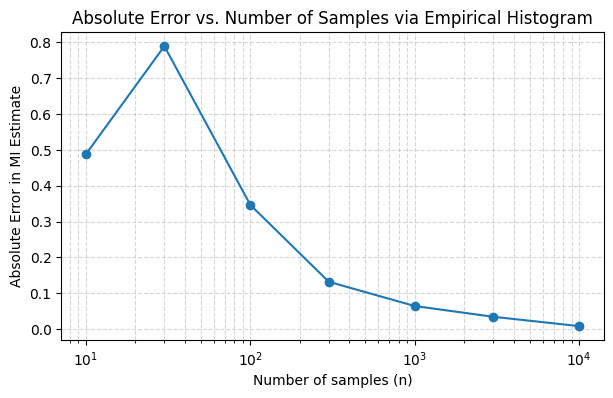

In [131]:
def empirical_mutual_information(data, num_bins):
    n = data.shape[0]
    sample_x = data[:, 0]
    sample_y = data[:, 1]
    
    # Compute empirical joint histogram (joint probability) from samples
    empirical_joint, _, _ = np.histogram2d(sample_x, sample_y, bins=[num_bins, num_bins], range=[[0, num_bins], [0, num_bins]], density=False)
    empirical_joint = empirical_joint / n  # normalize to make it a probability

    # Compute empirical marginals
    empirical_p_x = np.sum(empirical_joint, axis=1)
    empirical_p_y = np.sum(empirical_joint, axis=0)

    # Compute mutual information from empirical distributions
    empirical_mi = 0.0
    for i in range(num_bins):
        for j in range(num_bins):
            pxy = empirical_joint[i, j]
            if pxy > 0:  # Avoid log(0)
                empirical_mi += pxy * np.log(pxy / (empirical_p_x[i] * empirical_p_y[j]))

    return empirical_mi

empirical_mi = empirical_mutual_information(sample_data, num_bins=support_size)
error = abs(empirical_mi - true_mi)
print('Empirical Mutual Information (from samples):', empirical_mi)
print('Ground Truth Mutual Information (from joint):', true_mi)
print('Absolute Error in Mutual Information Estimate:', error)

datalevels = [10, 30, 100, 300, 1000, 3000, 10000]
histogram_errors = []
for n in datalevels:
    mi_hat = empirical_mutual_information(sample_data[:n], num_bins=support_size)
    abs_error = abs(mi_hat - true_mi)
    histogram_errors.append(abs_error)

plt.figure(figsize=(7,4))
plt.plot(datalevels, histogram_errors, marker='o')
plt.xlabel('Number of samples (n)')
plt.ylabel('Absolute Error in MI Estimate')
plt.title('Absolute Error vs. Number of Samples via Empirical Histogram')
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

### Mutual Information Neural Estimation (MINE)

MINE: Mutual Information Neural Estimation (https://arxiv.org/abs/1801.04062) is a method to estimate Mutual Information by parametrizing the statistic $T(X, Y)$ in the Donsker-Varadhan representation of the KL Divergence

$$
D(P \| Q) = \sup_{T: \mathcal{X} \to \mathbb{R}} \mathbb{E}_P [T] - \log \mathbb{E}_Q [e^{T}]
$$

Recalling that $I(X; Y) = D_{KL}(p_{XY} || p_Xp_Y)$, and letting $T$ be parametrized by some neural network $T_\theta: \mathcal{X} \times \mathcal{Y} \rightarrow \mathbb{R}$. We get the following expression which we can solve with gradient ascent.


$$
I(X; Y) \approx \sup_{\theta} \mathbb{E}_{p_{XY}} [T_\theta(X, Y)] - \log \mathbb{E}_{p_Xp_Y} [e^{T_\theta(X, Y)}]
$$



One thing to notice is that $T^*(X, Y) = \log\left(\frac{p_{XY}(X, Y)}{p_X(X)p_Y(Y)}\right)$ 

since 
$$\mathbb{E}_{p_{XY}}\left\{\log\left(\frac{p_{XY}(X, Y)}{p_X(X)p_Y(Y)}\right)\right\} = D_{KL}(p_{XY}||p_Xp_Y)$$ 

and

$$\log \mathbb{E}_{p_Xp_Y}\!\left[e^{T^*(X,Y)}\right]
= \log \mathbb{E}_{p_Xp_Y}\!\left[\frac{p_{XY}(X,Y)}{p_X(X)p_Y(Y)}\right] = 0$$

since

$$\mathbb{E}_{p_Xp_Y}\!\left[\frac{p_{XY}(X,Y)}{p_X(X)p_Y(Y)}\right]
= \sum_{x,y} p_X(x)p_Y(y)\,\frac{p_{XY}(x,y)}{p_X(x)p_Y(y)}
= \sum_{x,y} p_{XY}(x,y)
= 1$$

Meaning that the $\text{first term} - \text{second term} = D_{KL}(p_{XY}||p_Xp_Y) - 0 = I(X; Y)$

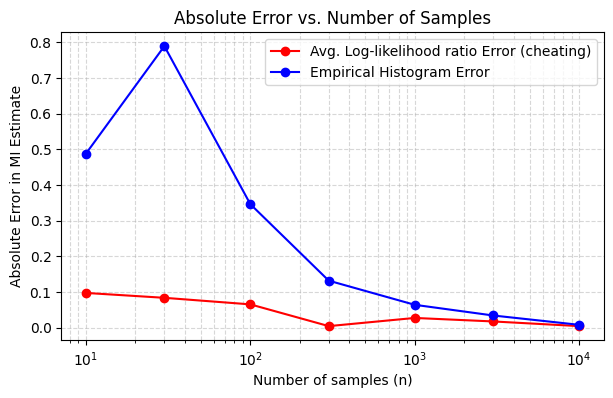

In [132]:
import torch # use torch so we can hot swap with this class with a MLP later on

# Preliminarily, we can build a callable LogLikelihoodRatio class to be our optimal T
class LogLikelihoodRatio:
    def __init__(self, p_xy, pxpy):
        """
        Store the p_xy and pxpy distributions.
        """
        self.p_xy = torch.tensor(p_xy)
        self.pxpy = torch.tensor(pxpy)

    def __call__(self, xys):
        """
        xys: tensor of shape (B, D) where is the number of dimensions in the 
        distributions self.p_xy and self.pxpy.
        """

        assert xys.dtype == torch.long, "LogLikelihoodRatio object must be passed in integer tensors"

        p_xys = self.p_xy[xys[:, 0], xys[:, 1]]
        pxpy_xys = self.pxpy[xys[:, 0], xys[:, 1]]

        return (torch.log(p_xys + 1e-20) - torch.log(pxpy_xys + 1e-20)).unsqueeze(1)

T_optimal = LogLikelihoodRatio(p_xy = p_xy, pxpy = pxpy)


datalevels = [10, 30, 100, 300, 1000, 3000, 10000]
ELLR_errors = []
for n in datalevels:
    data_tensor = torch.LongTensor(sample_data[:n])
    mi_hat = T_optimal(data_tensor).mean() # find the mean of the LL ratios
    abs_error = abs(mi_hat - true_mi)
    ELLR_errors.append(abs_error)

plt.figure(figsize=(7,4))
plt.plot(datalevels, ELLR_errors, marker='o', color='red', label='Avg. Log-likelihood ratio Error (cheating)')
plt.plot(datalevels, histogram_errors, marker='o', color='blue', label='Empirical Histogram Error')
plt.xlabel('Number of samples (n)')
plt.ylabel('Absolute Error in MI Estimate')
plt.title('Absolute Error vs. Number of Samples')
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [133]:
# We can define an evaluate function to evaluate the 
# DV representaiton given some T and some data.

def evaluate_DV(T, joint_data, marginal_data):
    """
    T: a callable object that eats a batch of torch.long indices and spits out a sclar
    joint_data: (2, N) tensor of data (integer valued)
    marginal_data: (2, N) tensor of data (integer valued)
    """

    with torch.no_grad():
        
        joint_scores = T(joint_data)
        marginal_scores = T(marginal_data)
        
        joint_scores_mean = joint_scores.mean()
        log_E_exp_marginal_scores_mean = torch.log((torch.exp(marginal_scores)).mean())

        mi_est = joint_scores_mean - log_E_exp_marginal_scores_mean

    return mi_est.item()

# As a sanity check 
sample_data_tensor = torch.tensor(sample_data, dtype=torch.long)
marginal_data_tensor = torch.tensor(marginal_data, dtype=torch.long)

optimal_DV_estimate = evaluate_DV(T_optimal, sample_data_tensor, marginal_data_tensor)
print("Estimated MI (DV, analytic T):", optimal_DV_estimate)
print("True MI:", true_mi)
print("Absolute error:", abs(optimal_DV_estimate - true_mi))

Estimated MI (DV, analytic T): 0.18667286620402268
True MI: 0.18510107394837735
Absolute error: 0.0015717922556453268


In [134]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm, trange

class MLP(nn.Module):
    def __init__(self, num_bins, h=64):
        super().__init__()
        self.num_bins = num_bins
        self.net = nn.Sequential(
            nn.Linear(2, h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, 1)
        )

    def forward(self, x):
        assert x.dtype == torch.long, "T networks expect inputs to be index pairs"
        x.to(torch.float32)
        x = x / self.num_bins
        return self.net(x)


T_theta = MLP(num_bins = support_size)

test_idxs = torch.LongTensor([[0,0], [0, 1], [2, 1]])

# B, 2 -> 2, 1
print("T_optimal (LL Ratio): ", T_optimal(test_idxs).tolist())

joint_data = sample_data # ~ p(x, y), 
xs, ys = sample_data[:, 0], sample_data[:, 1]
ys_shuffled = np.random.permutation(ys)
marginal_data = np.stack([xs, ys_shuffled], axis=1) # ~ p(x)p(y)

T_optimal (LL Ratio):  [[0.17973357127973077], [0.6224314207567652], [0.5104415176528212]]


The update for the network can be expressed as:
$$
\widehat{G}_B
=
\mathbb{E}_B\!\left[\nabla_\theta T_\theta\right]
-
\frac{
\mathbb{E}_B\!\left[\nabla_\theta e^{T_\theta}\right]
}{
\mathbb{E}_B\!\left[e^{T_\theta}\right]
}.
$$

This differs from (12) because I write $\mathbb{E}_B\!\left[\nabla_\theta e^{T_\theta}\right]$ instead of $\mathbb{E}_B\!\left[\nabla_\theta T_\theta \, e^{T_\theta}\right]$ in the numerator of the second term, but they are equal and the former is easier for torch autograd.

In [135]:
def update_dir(T_theta, joint_batch, marginal_batch, exp_T_pxpy_ema):
    """
    T_theta: a torch.nn.module MLP to represent T_theta 
    joint_batch: (2, N) tensor of data (integer valued)
    marginal_batch: (2, N) tensor of data (integer valued)
    """

    # not optimizing the input
    joint_batch.requires_grad = False  
    marginal_batch.requries_grad = False

    # compute E_pxy[\nabla T]
    output_joint_mean = T_theta(joint_batch).mean()
    joint_grads = torch.autograd.grad(output_joint_mean, T_theta.parameters(), create_graph=False)

    # compute E_pxpy[(\nabla T)exp(T)] = E_pxpy[\nabla exp(T)]
    output_marginal = T_theta(marginal_batch)
    exp_output_marginal_mean = torch.exp(output_marginal).mean()
    marginal_grads = torch.autograd.grad(exp_output_marginal_mean, T_theta.parameters(), create_graph=False)

    scale = 1.0 / float(exp_T_pxpy_ema)   # scalar python float is fine
    d = tuple(gj - scale * gm for gj, gm in zip(joint_grads, marginal_grads)) 
    return d

In [136]:
def mine(data, support_size, lr=1e-3, n_updates=500, batch_size=128, plot_validation_error=False): 
    # print(f"Starting Mutual Information Neural Estimation with {len(data)} data points")
    
    batch_size = min(batch_size, len(data))
    joint_data = data # ~ p(x, y), 

    xs, ys = data[:, 0], data[:, 1]
    ys_shuffled = np.random.permutation(ys)
    marginal_data = np.stack([xs, ys_shuffled], axis=1) # ~ p(x)p(y)
    
    joint_data_tensor = torch.tensor(joint_data, dtype=torch.long)
    marginal_data_tensor = torch.tensor(marginal_data, dtype=torch.long)


    T_theta = MLP(num_bins=support_size)
    exp_T_pxpy_ema = torch.exp(T_theta(marginal_data_tensor)).mean() # warmstart with raw network's value
    
    errors = []
    steps_recorded = []
    for step in trange(n_updates):
        
        batch_indices = torch.randperm(joint_data_tensor.size(0))[:batch_size]
        joint_batch = joint_data_tensor[batch_indices]
        marginal_batch = marginal_data_tensor[batch_indices]

        # evaluation and error recording only every 50 steps
        if step % 50 == 0:
            mi_estimate = evaluate_DV(T_theta, joint_data_tensor, marginal_data_tensor)
            errors.append(abs(mi_estimate - true_mi))
            steps_recorded.append(step)

        # ema implementation since ratio exp(ratio) != ratio expectations (see more in section 3.2 of MINE paper)
        exp_T_pxpy_minibatch = torch.exp(T_theta(marginal_batch)).mean()
        exp_T_pxpy_ema = 0.9 * exp_T_pxpy_ema  + 0.1 * exp_T_pxpy_minibatch

        # Update and step logic
        grads = update_dir(T_theta, joint_batch, marginal_batch, exp_T_pxpy_ema)

        with torch.no_grad():
            for p, g in zip(T_theta.parameters(), grads):
                p += lr * g

    if plot_validation_error:
        plt.figure(figsize=(10, 5))
        plt.plot(steps_recorded, errors, label='Absolute Error')
        plt.xlabel('Step')
        plt.ylabel('Error')
        plt.title('MINE Training Error Over Time')
        plt.legend()
        plt.show()

    return evaluate_DV(T_theta, joint_data_tensor, marginal_data_tensor) 

# mine(sample_data, support_size = support_size, n_updates=50000, lr=1e-1, batch_size=1024, plot_validation_error=True)



Warning: the mine implementation about returns NaN more often than I would like at the moment. This is definitely fixable, but I will put this off until later.

100%|██████████| 50000/50000 [00:18<00:00, 2698.88it/s]


MINE run returned NaN for n=30, retrying (1/5)...


100%|██████████| 50000/50000 [00:21<00:00, 2373.57it/s]


MINE run returned NaN for n=100, retrying (1/5)...


100%|██████████| 50000/50000 [00:21<00:00, 2375.55it/s]


...

100%|██████████| 50000/50000 [00:29<00:00, 1716.99it/s]


MINE run returned NaN for n=300, retrying (4/5)...


100%|██████████| 50000/50000 [00:29<00:00, 1696.13it/s]


MINE run returned NaN for n=300, retrying (5/5)...


100%|██████████| 50000/50000 [01:13<00:00, 676.71it/s]


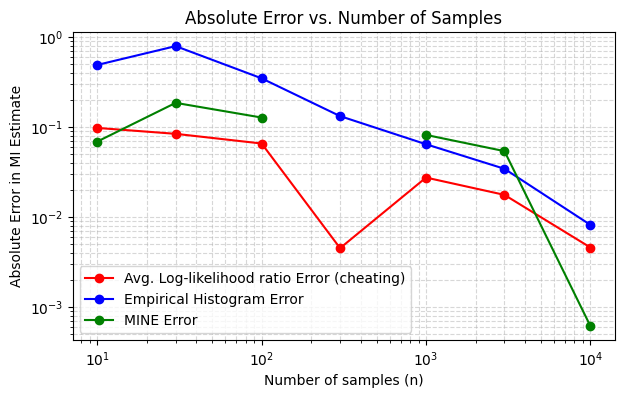

In [137]:
import math

datalevels = [10, 30, 100, 300, 1000, 3000, 10000]
MINE_errors = []
max_retries = 5

for n in datalevels:
    retry = 0
    mine_pred = None
    # Repeat run if mine_pred is nan, up to max_retries
    while retry < max_retries:
        mine_pred = mine(sample_data[:n], support_size, n_updates=50000, batch_size=1024, lr=1e-1)
        if mine_pred is not None and not (isinstance(mine_pred, float) and math.isnan(mine_pred)):
            break
        retry += 1
        print(f"MINE run returned NaN for n={n}, retrying ({retry}/{max_retries})...")
    if mine_pred is None or (isinstance(mine_pred, float) and math.isnan(mine_pred)):
        print(f"Warning: Unable to get valid MINE prediction for n={n} after {max_retries} retries. Appending NaN.")
        abs_error = float('nan')
    else:
        abs_error = abs(mine_pred - true_mi)
    MINE_errors.append(abs_error)

plt.figure(figsize=(7,4))
plt.plot(datalevels, ELLR_errors, marker='o', color='red', label='Avg. Log-likelihood ratio Error (cheating)')
plt.plot(datalevels, histogram_errors, marker='o', color='blue', label='Empirical Histogram Error')
plt.plot(datalevels, MINE_errors, marker='o', color='green', label='MINE Error')
plt.xlabel('Number of samples (n)')
plt.ylabel('Absolute Error in MI Estimate')
plt.title('Absolute Error vs. Number of Samples')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()